**Data Cleaning and Visualization Project**

**Database link :**
https://drive.google.com/file/d/17Q9zLpzu4Hs19GWlyTFQ4cIvQmYoZB-R/view?usp=sharing

---


**Project** **Overview**

📊 **Retail** **Sales** **Data** **Cleaning** **and** **Preprocessing** **Project**

---

**Executive** **Summary**

This project presents a structured and professional approach to transforming a raw and intentionally disordered retail sales dataset into a clean, analysis-ready format. Instead of focusing purely on removing missing values, the project emphasizes correctness, logical relationships, and responsible decision-making.

All preprocessing steps were performed in controlled phases, supported by business logic validation and mathematical consistency checks. Wherever uncertainty could not be resolved safely, values were intentionally preserved as missing rather than forcing artificial completion.

The final dataset ensures reproducibility, transparency, and analytical reliability — aligning with real-world data engineering standards.

---

**1. Project Overview**

  **1.1** **Dataset** **Characteristics**

  * **Total Records:** 12,575 retail transactions
  * **Total Columns:** 11 attributes describing purchase activity
  * **Scope:** Multiple product categories across repeated customers
  * **Data Nature:** Intentionally introduced missing values, inconsistencies, and logical irregularities to simulate real-world messy datasets

This dataset provides a practical scenario for applying advanced data cleaning techniques.

---

**1.2 Project Objectives**

✅ Validate and correct inaccurate values using business rules

✅ Maintain mathematical and logical dependencies across columns

✅ Apply transparent and documented cleaning decisions

✅ Follow professional data quality standards

✅ Avoid bias caused by unnecessary imputation

**Key Principle**

The objective is not to eliminate every null value.
The objective is to ensure every retained value is logically valid and trustworthy.

---

**2. Methodology and Guiding Principles**

**2.1 Strategic Approach**

The cleaning workflow followed a staged and controlled execution model.

Each phase included intermediate checkpoints to ensure:

Reproducibility of steps

Error rollback capability

Clear audit trail

Version comparison

Three intermediate versions were exported:

**v1 –** After initial reconstruction

**v2 –** After discount and spending inference

**v3 –** Final cleaned dataset

---


**2.2 Core Principles**

| Principle                     | Practical Implementation                                 |
| ----------------------------- | -------------------------------------------------------- |
| Validate Before Filling       | Mathematical relationships checked prior to imputation   |
| Evidence-Based Inference      | Values inferred only when logically provable             |
| Preserve Uncertainty          | Missing values retained where ambiguity exists           |
| Explicit Documentation        | All actions and non-actions recorded clearly             |
| Dependency Awareness          | Column interrelationships considered before modification |
| Transparency Through Flagging | Indicator columns created for inferred values            |

---

**3. Detailed Cleaning Process**

---

**Phase 1: Loading and Initial Exploration**

 **Actions Performed**

*   Imported dataset into pandas DataFrame
*   Reviewed structure using .shape(), .info(), .describe()
*   Previewed records using .head() and .tail()
*   Evaluated missing values using .isnull().sum()

 **Outcome**

Gained full understanding of data structure, inconsistencies, and cleaning priorities.

---

**Phase 2: Structural Cleanup**

**Column Name Standardization**

*   Removed extra spaces
*   Converted to lowercase
*   Replaced spaces with underscores

**Example:**

Price Per Unit → price_per_unit

**Reason:** Improves readability, avoids referencing errors, and follows Python naming conventions.

---

**Granularity Verification**

*   Confirmed uniqueness of transaction_id
*   Validated repeated customer_id values

Ensured dataset operates at transaction-level granularity.

---

**Duplicate and Unusable Row Removal**

*   Checked for exact duplicates (none found)
*   Removed rows missing all critical fields (discount_applied, price_per_unit, item)

Such rows lacked sufficient transactional information for analysis.

---

**Phase 3: Categorical Field Validation**

**Clean Categorical Fields**

Analyzed category and payment_method using .value_counts().

Findings:

* Low cardinality

* Consistent formatting

* No missing values

Decision: No modification required.

---

**Item Field Reconstruction**

**Challenge:** Missing product names in item column.

**Approach:**

1. Examined relationships between category, price_per_unit, and item

2. Created lookup table mapping (category, price_per_unit) → item

3. Selected only one-to-one mappings

4. Applied controlled filling

5. Added item_was_missing flag

**What Was Avoided**

* No artificial values created

* No probabilistic filling

* Ambiguous cases intentionally left missing

Outcome: Partial reconstruction while preserving data integrity.

---

**Phase 4: Numerical Field Reconstruction**

---

**Step 4.1: Price Per Unit**

Reconstructed using:

price_per_unit = total_spent / quantity

Conditions applied:

* total_spent available

* quantity positive

* Transaction not discounted

Flag added: price_reconstructed

Discounted rows excluded to maintain accuracy.

---

**Step 4.2: Total Spent (Two-Stage Approach)**

**Stage 1: Mathematical Reconstruction**

**If:**

* price_per_unit known

* quantity known

* discount_applied = False

**Then:**

total_spent = price_per_unit × quantity

Flagged with total_spent_inferred.

---

**Stage 2: Statistical Estimation**

* Calculated median spending per (customer_id, category)

* Applied only when sufficient historical data existed

* Median chosen to reduce impact of outliers

Flagged with total_spent_estimated.

---

**Step 4.3: Discount Applied**

Defined tolerance (TOL) for floating-point precision.

If difference between calculated and recorded total within tolerance:

discount_applied = False

Existing True values were never overwritten.

Converted to nullable Boolean type.

Flag added: discount_inferred.

---

**Step 4.4: Quantity (Intentional Non-Imputation)**

**Validation confirmed:**

* No zero values

* No negative values

* No fractional quantities

Tested reconstruction:

quantity = total_spent / price_per_unit

No safe inference cases identified.

Decision: No imputation performed.

Reason: Quantity is a fundamental transactional variable; guessing would introduce bias.

---

**Phase 5: Temporal Data Handling**

* Converted transaction_date to datetime format

* Invalid entries coerced to NaT

Ensures compatibility for time-based analysis.

---

**Phase 6: Version Control**

Intermediate datasets exported:

* retail_sales_intermediate_v1.csv

* retail_sales_intermediate_v2.csv

* retail_sales_cleaned.csv

Provides audit trail and reproducibility.

---

**4. Final Data Quality Assessment**

---

4.1 Remaining Missing Values

| Column           | Justification              |
| ---------------- | -------------------------- |
| quantity         | Cannot be safely inferred  |
| total_spent      | Dependent on quantity      |
| price_per_unit   | Discounted/ambiguous cases |
| item             | Non-unique mappings        |
| discount_applied | Insufficient evidence      |

**Key Insight**

Missing values were retained only where safe inference was not possible.

---

**4.2 Transparency Flags Created**

| Flag Column           | Purpose                       |
| --------------------- | ----------------------------- |
| price_reconstructed   | Identifies calculated prices  |
| item_was_missing      | Indicates reconstructed items |
| discount_inferred     | Marks inferred discounts      |
| total_spent_inferred  | Mathematical totals           |
| total_spent_estimated | Median-based estimates        |


These ensure full auditability of transformations.

---

4.3 Quality Improvements Achieved

✅ Logical consistency maintained

✅ Proper data typing applied

✅ Transparent inference tracking

✅ Dependency-aware reconstruction

✅ Analysis-ready structure

✅ Fully auditable dataset

**5. Key Learnings and Best Practices**

* Missing values should not always be force-filled

* Mathematical validation strengthens reliability

* Flagging improves transparency

* Cleaning must consider column dependencies

* Documenting non-actions is equally important

---

**6. Technical Skills Demonstrated**

**Python & Pandas**

* Data import and export

* Exploratory analysis

* Conditional transformations

* Group-based aggregation

* Nullable dtype handling

* Lookup mapping

**Data Engineering Principles**

* Incremental processing

* Version checkpointing

* Audit trail creation

* Business rule validation

**Analytical Thinking**

* Risk-aware inference

* Logical dependency evaluation

* Trade-off assessment

* Root cause investigation

---

**7. Final Deliverables**

**7.1 Cleaned Datasets**

* retail_sales_intermediate_v1.csv

* retail_sales_intermediate_v2.csv

* retail_sales_cleaned.csv

**7.2 Dataset Characteristics**

✅ Logically consistent

✅ Semantically typed

✅ Transparent assumptions

✅ Analysis-ready

---

**8. Conclusion**

This project demonstrates a disciplined and production-level approach to data cleaning. The emphasis was placed on integrity, logical correctness, and responsible inference rather than superficial completeness.

By applying structured reconstruction, dependency-aware validation, and transparent flagging, the dataset was transformed into a reliable analytical asset.

**Core Achievement**

Converted intentionally messy retail transaction data into a clean, auditable, and analysis-ready dataset while maintaining full transparency in every transformation decision — reflecting professional data engineering standards.

# **imports**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Cleaning

**Loading and initial exploration**

* Imported the raw retail sales data from CSV into a pandas DataFrame for further cleaning and analysis.

* Checked the overall size and structure of the dataset using .shape, .head(), and .tail() to understand row/column counts and sample records.

* Used .info() and .describe() to review data types, numerical distributions, and potential issues such as missing values or unexpected ranges.

* Computed column-wise null counts with .isnull() , .sum() to get an initial overview of data completeness.

In [ ]:
df = pd.read_csv("retail_store_sales.csv")

In [ ]:
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


In [ ]:
print(df.shape)

(12575, 11)


In [ ]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [ ]:
df.tail()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True
12574,TXN_2407494,CUST_23,Food,Item_9_FOOD,17.0,3.0,51.0,Cash,Online,2022-08-06,NaN


In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,609
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [ ]:
print(df.describe(include = "number").T)
print()
print(df.describe(include = "O").T)
print()
# print(df.describe(include = "all").T)

                  count        mean        std  min   25%    50%    75%    max
Price Per Unit  11966.0   23.365912  10.743519  5.0  14.0   23.0   33.5   41.0
Quantity        11971.0    5.536380   2.857883  1.0   3.0    6.0    8.0   10.0
Total Spent     11971.0  129.652577  94.750697  5.0  51.0  108.5  192.0  410.0

                  count unique                            top  freq
Transaction ID    12575  12575                    TXN_2407494     1
Customer ID       12575     25                        CUST_05   544
Category          12575      8  Electric household essentials  1591
Item              11362    200                     Item_2_BEV   126
Payment Method    12575      3                           Cash  4310
Location          12575      2                         Online  6354
Transaction Date  12575   1114                     2022-05-30    26
Discount Applied   8376      2                           True  4219



**Standardizing column names**

* Removed extra spaces, converted names to lowercase, and replaced spaces with underscores to create consistent, analysis-friendly column names.

* Ensured all columns follow a uniform naming convention, which simplifies querying, feature engineering, and reuse of the dataset in other notebooks.

* Verified the updated schema with .info() and summary statistics to confirm that only labels changed, not the underlying data.

In [ ]:
df.columns

Index(['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit',
       'Quantity', 'Total Spent', 'Payment Method', 'Location',
       'Transaction Date', 'Discount Applied'],
      dtype='object')

In [ ]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")

In [ ]:
df.columns

Index(['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit',
       'quantity', 'total_spent', 'payment_method', 'location',
       'transaction_date', 'discount_applied'],
      dtype='object')

**Duplicate check and dropping unusable rows**

* Checked for fully duplicated rows using .duplicated() , .sum() to confirm there were no exact duplicate records in the dataset.​

* Dropped rows where discount_applied , price_per_unit and item were all missing, because such records lack core transactional details and cannot support meaningful analysis.​

* Recomputed missing value counts to validate that only non‑informative rows were removed and that data quality improved without significant information loss.

In [ ]:
df.duplicated().sum()
# no duplicates found

np.int64(0)

droping columns:

* where discount_applied , price_per_unit and item all are null because respective data can not be used for any analysis.

In [ ]:
df.dropna(subset = ["discount_applied", "price_per_unit","item"],how="all",inplace=True)

In [ ]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
category,0
item,1008
price_per_unit,404
quantity,604
total_spent,604
payment_method,0
location,0
transaction_date,0


**Column-wise inspection: category and payment method**

* Examined the distribution of category using .value_counts() to confirm all entries were valid and that there were no missing or inconsistent category labels.​

* Checked payment_method values to ensure there were no unexpected codes or nulls, confirming that this field is clean and ready for downstream analysis (e.g., payment mix or preferences).​

* Decided that neither category nor payment_method required corrective cleaning, since both columns showed complete and consistent data.

In [ ]:
df["category"].value_counts()

,count
category,
Furniture,1571
Electric household essentials,1563
Food,1562
Milk Products,1554
Beverages,1546
Butchers,1545
Computers and electric accessories,1529
Patisserie,1500


In [ ]:
df["payment_method"].value_counts()

,count
payment_method,
Cash,4246
Credit Card,4063
Digital Wallet,4061


**Investigating and reconstructing item and price_per_unit**

* Identified missing values in the item column and investigated how item information relates to category , price_per_unit , quantity , and total_spent .

* Reconstructed price_per_unit where possible by using the relationship price_per_unit = total_spent / quantity for rows with valid totals, positive quantity, and no discount applied.

* Tracked all reconstructed prices in a helper flag column price_reconstructed to maintain transparency about which records were inferred versus originally present.​

In [ ]:
df["item"].isnull().sum()

np.int64(1008)

In [ ]:
df['price_reconstructed'] = False

mask = (
    df['price_per_unit'].isna() &
    df['total_spent'].notna() &
    df['quantity'].notna() &
    (df['quantity'] > 0) &
    (df['discount_applied'] == False)
)

df.loc[mask,'price per unit'] = (
    df.loc[mask,'total_spent'] / df.loc[mask,'quantity']
)

df.loc[mask, 'price_reconstructed'] = True

In [ ]:
df['price_reconstructed'].value_counts()

# 186 values changed

,count
price_reconstructed,
False,12184
True,186


In [ ]:
df['price per unit'].isnull().sum()

np.int64(12184)

* These prices are empty because of one of the column used to calculate must be empty

**Inferring item names from category–price patterns**

* Built a reference table of **unique item values** grouped by category and price_per_unit to identify stable mappings between categories, prices and item names.

* Filtered this reference to “safe” mappings where a given category, price_per_unit pair corresponds to exactly one item, reducing the risk of incorrect imputations.

* Merged these safe mappings back into the main DataFrame and filled missing item values with the inferred names, leaving ambiguous cases as missing.

* Added an item_was_missing flag to record which records originally lacked item information and to facilitate auditing or sensitivity checks later.​

In [ ]:
# refrence table

item_ref = (
    df[df['item'].notna()]
    .groupby(['category','price_per_unit'])['item']
    .unique()
    .reset_index()
)

# keeping mappings where only one mapping exists

item_ref['item_count'] = item_ref['item'].apply(len)
safe_item_ref = item_ref[item_ref['item_count']==1]

# extract single line

safe_item_ref['inferred_item'] = safe_item_ref['item'].apply(lambda x: x[0])

safe_item_ref = safe_item_ref[['category','price_per_unit','inferred_item']]

In [ ]:
item_ref

,category,price_per_unit,item,item_count
0,Beverages,5.0,[Item_1_BEV],1
1,Beverages,6.5,[Item_2_BEV],1
2,Beverages,8.0,[Item_3_BEV],1
3,Beverages,9.5,[Item_4_BEV],1
4,Beverages,11.0,[Item_5_BEV],1
...,...,...,...,...
195,Patisserie,35.0,[Item_21_PAT],1
196,Patisserie,36.5,[Item_22_PAT],1
197,Patisserie,38.0,[Item_23_PAT],1
198,Patisserie,39.5,[Item_24_PAT],1


In [ ]:
# merge to df

df = df.merge(safe_item_ref,on=['category','price_per_unit'],how='left')
df

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date,discount_applied,price_reconstructed,price per unit,inferred_item
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,False,NaN,Item_10_PAT
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,False,NaN,Item_17_MILK
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,False,NaN,Item_12_BUT
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN,False,NaN,Item_16_BEV
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,False,NaN,Item_6_FOOD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12365,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN,False,NaN,Item_23_PAT
12366,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False,False,NaN,Item_2_BEV
12367,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN,False,NaN,Item_7_BUT
12368,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True,False,NaN,Item_7_FUR


In [ ]:
#  fill missing values

df['item'] = df['item'].fillna(df['inferred_item'])
df.drop(columns=['inferred_item'],inplace=True)
df['item_was_missing'] = df['item'].isna()

In [ ]:
df['item_was_missing'].value_counts()

,count
item_was_missing,
False,11966
True,404


In [ ]:
print("Shape : ", df.shape)
print("Missing price_per_unit : ",df['price per unit'].isna().sum())
print("Missing Item : ",df['item'].isna().sum())

Shape :  (12370, 14)
Missing price_per_unit :  12184
Missing Item :  404


**Exporting intermediate cleaned versions**

* Saved the partially cleaned dataset (with reconstructed prices and improved item information) to retail_sales_intermediate_v1.csv for versioning and backup.​

* This intermediate export allows rolling back or comparing different cleaning strategies without re-running the entire pipeline.

In [ ]:
temp_path = "retail_sales_intermediate_v1.csv"
df.to_csv(temp_path,index=False)

**Inferring discount_applied where possible**

* Identified rows with missing discount_applied but valid price_per_unit , quantity and total_spent to see if a discount logically occurred.

* Used a small tolerance TOL to compare price_per_unit * quantity with total_spent; when they matched within the threshold, the transaction was labeled as having no discount False.

* Recorded which discount flags were inferred in a helper column discount_inferred to preserve visibility into imputed values versus original entries.

In [ ]:
TOL = 0.01

In [ ]:
mask = (
    df['discount_applied'].isna() &
    df['price_per_unit'].notna() &
    df['quantity'].notna() &
    df['total_spent'].notna() &
    (df['quantity'] > 0) &
    (
        (df['price_per_unit'] * df['quantity'] - df['total_spent']).abs() < TOL
    )
)

In [ ]:
df.loc[mask, 'discount_applied'] = False
df['discount_inferred'] = False
df.loc[mask,'discount_inferred'] = True

**Estimating remaining total_spent via customer–category medians**

* For rows where total_spent was still missing, computed the median spending per customer_id , category group using all available non‑null transactions.

* Merged these median values into the main DataFrame and used them to estimate total_spent where the group median was available, flagging these rows in total_spent_estimated.

* Chose the median instead of the mean to reduce the influence of extreme outliers and better represent typical spending behavior within each customer–category combination.

* Dropped the temporary median_spent column after imputation and exported another intermediate snapshot as retail_sales_intermediate_v2.csv.

In [ ]:
df['total_spent_inferred'] = False

In [ ]:
mask = (
    df['total_spent'].isna() &
    df['price_per_unit'].notna() &
    df['quantity'].notna() &
    (df['quantity'] > 0) &
    (df['discount_applied'] == False)
)

In [ ]:
df.loc[mask, 'total_spent'] = (
    df.loc[mask,'price_per_unit'] * df.loc[mask,'quantity']
)
df.loc[mask,'total_spent_inferred'] = True

In [ ]:
# title

df['total_spent'].isna().sum()

np.int64(604)

In [ ]:
df['total_spent_inferred'].sum()

np.int64(0)

In [ ]:
df['total_spent'].isnull().sum()

np.int64(604)

In [ ]:
MIN_COUNT = 3 # for applying changed where there are min 3 things bought inn the category

# using groupby to set median in a new dataframe before changing directly to new dataframe

cust_spent = (
    df[df['total_spent'].notna()]
    .groupby(['customer_id','category'])['total_spent']
    .agg(
        median_spent = 'median',
        count = 'count'
    )
    .reset_index()
)
cust_spent

,customer_id,category,median_spent,count
0,CUST_01,Beverages,78.00,63
1,CUST_01,Butchers,107.50,63
2,CUST_01,Computers and electric accessories,82.50,71
3,CUST_01,Electric household essentials,124.00,52
4,CUST_01,Food,98.00,67
...,...,...,...,...
195,CUST_25,Electric household essentials,75.00,59
196,CUST_25,Food,133.50,46
197,CUST_25,Furniture,86.75,54
198,CUST_25,Milk Products,70.00,57


In [ ]:
# cust_spent = cust_spent[
#     cust_spent['count'] >= MIN_COUNT
# ]
# cust_spent

# since no values less than 3 no need for this step

In [ ]:
# merging original dataframe

df = df.merge(
    cust_spent[['customer_id','category','median_spent']],
    on=['customer_id','category'],
    how='left'
)

In [ ]:
df

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date,discount_applied,price_reconstructed,price per unit,item_was_missing,discount_inferred,total_spent_inferred,median_spent
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,False,NaN,False,False,False,96.00
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,False,NaN,False,False,False,87.25
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,False,NaN,False,False,False,94.25
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False,False,NaN,False,True,False,104.50
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,False,NaN,False,False,False,119.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12365,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,False,False,NaN,False,True,False,103.00
12366,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False,False,NaN,False,False,False,130.50
12367,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,False,False,NaN,False,True,False,105.00
12368,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True,False,NaN,False,False,False,79.50


In [ ]:
# aplying where it is needed and checking where changes are applied

df['total_spent_estimated'] = False
mask = (
    df['total_spent'].isna() &
    df['median_spent'].notna()
)

df.loc[mask,'total_spent'] = df.loc[mask,'median_spent']
df.loc[mask,'total_spent_estimated'] = True

In [ ]:
df['total_spent_estimated'].sum()

np.int64(604)

In [ ]:
df['total_spent'].isna().sum()

np.int64(0)

In [ ]:
# drop median spent

df.drop(columns=['median_spent'],inplace=True)

In [ ]:
temp_path = "retail_sales_intermediate_v2.csv"
df.to_csv(temp_path,index=False)

**Final type conversions and validation**

* Converted transaction_date to a proper datetime type using pd.to_datetime , enabling reliable time-based analysis such as trends , seasonality and cohort tracking.

* Cast discount_applied to a nullable boolean type to reflect its true logical nature and to simplify filtering and aggregations on this field.​

* Saved the fully cleaned dataset to retail_sales_intermediate_v3.csv and rechecked shape and null counts to confirm the dataset is consistent, well‑typed, and ready for analysis or visualization.

In [ ]:
# changing relevant DTypes
df['transaction_date'] = pd.to_datetime(
    df['transaction_date'],
    errors='coerce'
)
df['discount_applied'] = (
    df['discount_applied'].astype('boolean')
)

In [ ]:
df.shape

(12370, 17)

In [ ]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
category,0
item,404
price_per_unit,404
quantity,604
total_spent,0
payment_method,0
location,0
transaction_date,0


**Additional cleaning for remaining null values**

In [ ]:
compare = (df['item'].isnull() & df['price per unit'])
compare.value_counts()

,count
False,12184
True,186


**Null Value Analysis and Decision**

* **Pattern Identified:** All null values in price_per_unit and item columns occur together in the same rows

* **Root Cause:** These missing values correspond exclusively to transactions where discount_applied = True

* **Why This Matters:**

* Discounted transactions lack the
original price_per_unit information
* Without the original price, the exact item cannot be reliably determined
* The discount amount/percentage is unknown, making reconstruction impossible

**Mathematical Limitation:**

* price_per_unit cannot be reverse-calculated from total_spent when discounts are applied
* Formula price_per_unit = total_spent / quantity only works for non-discounted transactions
* Unknown discount rate prevents accurate price recovery

**Impact on Analysis:**

* These records provide minimal statistical value without core pricing information
* Including them could skew revenue, pricing, and product mix analyses
* Missing price data prevents meaningful product-level insights
Decision Made: Drop all rows where both price_per_unit and item are null

**Justification:**

* Preserves data integrity by removing incomplete transactional records
* Prevents misleading statistical insights from partial data
* Focuses analysis on complete, reliable transactions
* Maintains logical consistency across the dataset

**Data Quality Trade-off:**

* Accept reduction in dataset size to maintain analytical reliability
* Prefer accurate analysis on complete data over biased analysis on incomplete data

In [ ]:
from re import sub
df.dropna(subset = ["price_per_unit","item"],how="all",inplace=True)
print(df.shape)

(11966, 17)


**Quantity and Discount Applied - Circular Dependency Issue**

* **Circular Dependency Identified:** quantity and discount_applied have mutual dependence

**Why These Cannot Be Inferred:**

* To infer quantity, we need: quantity = total_spent / price_per_unit
* This calculation is only valid when discount_applied = False
* Without knowing discount_applied status, we cannot safely calculate quantity

**Reverse Problem:**

* To infer discount_applied, we need to verify: price_per_unit × quantity ≈ total_spent
* Without knowing quantity, we cannot perform this mathematical validation
* Missing quantity prevents us from determining if a discount was applied

**Mathematical Constraint:**
* Both fields depend on each other for validation
* Neither can be reliably inferred without the other
* Any assumption(based on item or category) would introduce unverifiable bias

**Impact on Data Quality:**

* Records missing both fields lack fundamental transactional information
* Cannot validate pricing logic or transaction integrity
* Unusable for revenue analysis, sales metrics, or inventory calculations

* **Decision Made:** Drop all rows where both quantity and discount_applied are null

**Justification:**

* Eliminates records with irrecoverable core information
* Prevents cascading errors from incorrect assumptions
* Maintains mathematical consistency across remaining data
* Avoids circular inference that could introduce systematic bias

**Data Integrity Principle:**

* Better to remove incomplete records than introduce unfounded values
* Preserves reliability of remaining dataset for analysis
* Acknowledges limitations rather than masking them with guesses

In [ ]:
df.dropna(subset=["quantity","discount_applied"],how="all",inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11755 entries, 0 to 12369
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   transaction_id         11755 non-null  object        
 1   customer_id            11755 non-null  object        
 2   category               11755 non-null  object        
 3   item                   11755 non-null  object        
 4   price_per_unit         11755 non-null  float64       
 5   quantity               11362 non-null  float64       
 6   total_spent            11755 non-null  float64       
 7   payment_method         11755 non-null  object        
 8   location               11755 non-null  object        
 9   transaction_date       11755 non-null  datetime64[ns]
 10  discount_applied       11755 non-null  boolean       
 11  price_reconstructed    11755 non-null  bool          
 12  price per unit         0 non-null      float64       
 13  item_w

**Quantity Reconstruction - Safe Mathematical Inference**

**Current State:**

* Only quantity column has remaining null values
* All other columns (total_spent, price_per_unit, discount_applied) are fully populated
* This creates an opportunity for safe reconstruction

**Reconstruction Formula:**

  - quantity = total_spent / price_per_unit

**Application Condition:**

* Apply calculation only when discount_applied = False
* Skip reconstruction for discounted transactions (discount invalidates the formula)

**Safety Checks:**

* Verify total_spent is not null
* Verify price_per_unit is not null and greater than zero
* Confirm discount_applied = False before applying formula

**Implementation Logic:**

  IF (discount_applied = False) AND (total_spent is known) AND (price_per_unit > 0):
      quantity = total_spent / price_per_unit
  ELSE:
      LEAVE as null

**Post-Calculation Validation:**

* Round results to nearest integer (quantities must be whole numbers)
* Verify calculated quantities are positive
* Check for unrealistic values (e.g., extremely large quantities)

**Transparency:**

* Flag reconstructed quantities for audit trail
* Distinguish calculated values from original data

In [ ]:
mask = (df['discount_applied'] == False)
df.loc[mask,'quantity'] = (
    df.loc[mask,'total_spent'] / df.loc[mask,'price_per_unit']
)
df['quantity_reconstructed'] = False
df.loc[mask,'quantity_reconstructed'] = True

In [ ]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
category,0
item,0
price_per_unit,0
quantity,200
total_spent,0
payment_method,0
location,0
transaction_date,0


* Now the empty values are because of discount_applied is True

* To fill these values we can do two things:

1. Drop these rows

2. Filling using statastics

    Find an average discount value based on comparing actual_spent and total_spent where discount_applied is True.

    Based on avg discount use it for filling rest values such that quantity stays int

* Although statistical estimation of quantities based on discount behavior was considered, it was not applied due to the assumption-heavy nature of discount mechanisms and the risk of introducing fabricated transactional volumes.

* We will not drop them and use them in visuaization somewhere

In [ ]:
temp_path = "retail_sales_cleaned.csv"
df.to_csv(temp_path, index = False)

cleaned_dataset: https://drive.google.com/file/d/1-yjJBjUZgN-OIWrq8-jLXaDibXbATo2Q/view?usp=sharing

In [ ]:
# dropping flag columns
df.drop(columns = ['price_reconstructed','item_was_missing','discount_inferred','total_spent_inferred','total_spent_estimated','quantity_reconstructed'],inplace=True)

In [ ]:
df.columns

Index(['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit',
       'quantity', 'total_spent', 'payment_method', 'location',
       'transaction_date', 'discount_applied', 'price per unit'],
      dtype='object')

In [ ]:
df.shape

(11755, 12)

In [ ]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
category,0
item,0
price_per_unit,0
quantity,200
total_spent,0
payment_method,0
location,0
transaction_date,0


**Visualisation**



In [ ]:
df = pd.read_csv("retail_sales_cleaned.csv")

In [ ]:
df

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date,discount_applied,price_reconstructed,price per unit,item_was_missing,discount_inferred,total_spent_inferred,total_spent_estimated,quantity_reconstructed
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,False,NaN,False,False,False,False,False
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,False,NaN,False,False,False,False,False
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,False,NaN,False,False,False,False,True
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False,False,NaN,False,True,False,False,True
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,False,NaN,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11750,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,False,False,NaN,False,True,False,False,True
11751,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False,False,NaN,False,False,False,False,True
11752,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,False,False,NaN,False,True,False,False,True
11753,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True,False,NaN,False,False,False,False,False


**1️⃣ Revenue by Category (Bar Chart)**

* Helps identify high-value categories regardless of quantity uncertainty.


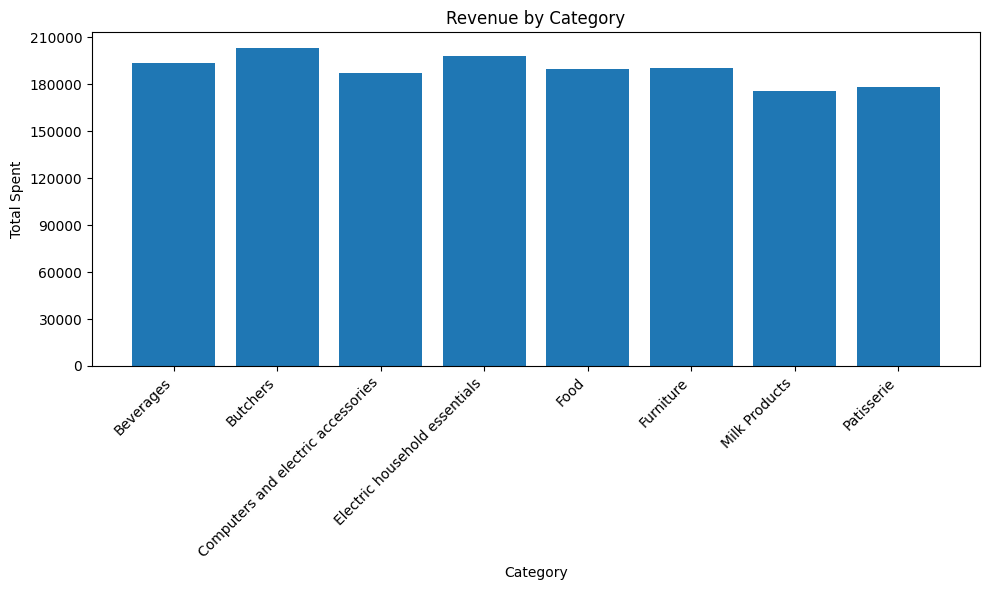

In [ ]:
cat_group = df.groupby('category')['total_spent'].sum().reset_index()
plt.figure(figsize=(10,6)) #set a suiable figure size
plt.bar(cat_group['category'],height = cat_group['total_spent'])
plt.xticks(rotation = 45, ha = 'right')
plt.yticks(np.arange(0,210001,30000))
plt.ylabel('Total Spent')
plt.xlabel('Category')
plt.title('Revenue by Category')
plt.tight_layout()
plt.show()

**📊Number of Transactions per Category(Bar Chart)**

This chart helps you distinguish between:

* High-frequency, low-ticket categories

* Low-frequency, high-ticket categories

That distinction is critical in retail analysis.



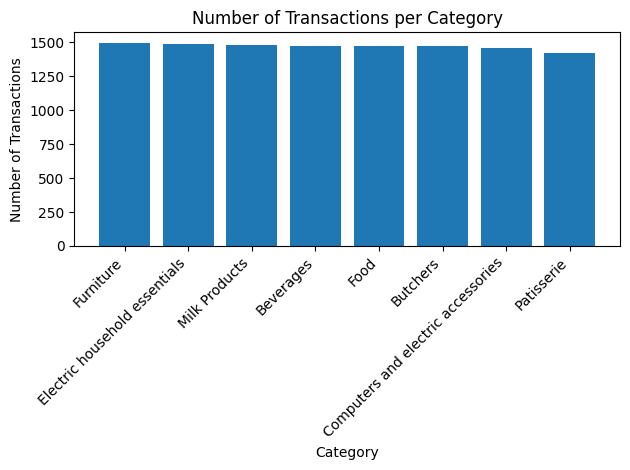

In [ ]:
trans_by_cat = (
    df.groupby("category")["transaction_id"].count().sort_values(ascending=False)
)
plt.figure()
plt.bar(trans_by_cat.index, trans_by_cat.values)
plt.xticks(rotation=45,ha="right")
plt.xlabel("Category")
plt.ylabel("Number of Transactions")
plt.title("Number of Transactions per Category")
plt.tight_layout()
plt.show()

**📊 Monthly Revenue Trend (Line Plot)**

* A line plot is ideal when the x-axis represents time and we want to understand trends, patterns, or changes.
* “How does total revenue change over time?”

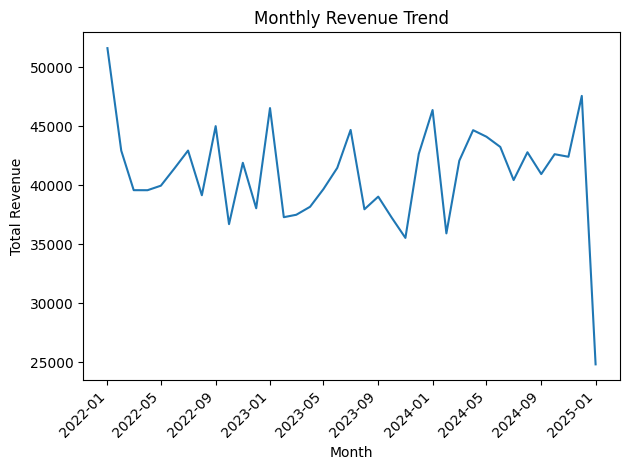

In [ ]:
# ensure transaction_date is datetime(Safe check)
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# create a year-month column
df["year_month"] = df["transaction_date"].dt.to_period("M")

# Aggregrate monthly revenue
monthly_revenue = (
    df.groupby("year_month")["total_spent"].sum().sort_index()
)

# convert periodIndex to timestamp for plotting
monthly_revenue.index = monthly_revenue.index.to_timestamp()

# plot
plt.figure()
plt.plot(monthly_revenue.index,monthly_revenue.values)
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()